# Paso 1: Importamos librerias

In [ ]:
# ==============================================================================
# CELDA 1: IMPORTACIÓN DE LIBRERÍAS NECESARIAS
# ==============================================================================
# Librerías para manipulación de datos y operaciones numéricas
import numpy as np
import pandas as pd

# TensorFlow y Keras para construir la red neuronal GAN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Librerías para visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de preprocesamiento de sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Configuración de estilo para gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Todas las librerías importadas correctamente")
print(f"   TensorFlow version: {tf.__version__}")

✅ Todas las librerías importadas correctamente
   TensorFlow version: 2.19.0


# Paso 2: Generación del Dataset Inicial

In [ ]:
# ==============================================================================
# CELDA 2: CREACIÓN DEL DATASET INICIAL DE DESARROLLADORES WEB
# ==============================================================================
# Este dataset simula datos reales del mercado laboral español/europeo
# de desarrolladores web con correlaciones realistas entre variables

print("="*80)
print("GENERANDO DATASET INICIAL DE DESARROLLADORES WEB")
print("="*80)

# Fijar semilla para reproducibilidad
np.random.seed(42)

# Número de perfiles a generar
n_samples = 5000

print(f"\n📊 Generando {n_samples:,} perfiles de desarrolladores...")

# ----- 1. VARIABLES DEMOGRÁFICAS -----
# Edad: distribución normal centrada en 30 años (±6 años de desviación)
# Rango: 22-55 años (edad típica de desarrolladores activos)
edad = np.random.normal(30, 6, n_samples).clip(22, 55).astype(int)

# Años de experiencia: distribución exponencial (muchos juniors, pocos seniors)
# Rango: 0-20 años
anos_experiencia = np.random.exponential(4, n_samples).clip(0, 20).round(1)

# ----- 2. VARIABLES LABORALES -----
# Horas semanales de trabajo (distribución realista española)
horas_semanales = np.random.choice(
    [35, 37.5, 40, 45],  # Opciones comunes en España
    n_samples,
    p=[0.1, 0.2, 0.6, 0.1]  # Probabilidades: 40h es lo más común
)

# Stack técnico (especialización del desarrollador)
stacks = ['Frontend', 'Backend', 'Fullstack', 'DevOps']
stack = np.random.choice(
    stacks,
    n_samples,
    p=[0.25, 0.25, 0.40, 0.10]  # Fullstack es más demandado
)

# Tipo de trabajo (tendencia post-COVID hacia remoto/híbrido)
tipo_trabajo = np.random.choice(
    ['Remoto', 'Presencial', 'Híbrido'],
    n_samples,
    p=[0.45, 0.20, 0.35]  # Remoto e híbrido dominan
)

# Tamaño de empresa donde trabaja
tamano_empresa = np.random.choice(
    ['Startup', 'Mediana', 'Grande', 'Freelance'],
    n_samples,
    p=[0.25, 0.30, 0.30, 0.15]
)

# ----- 3. VARIABLES DE FORMACIÓN -----
# Nivel de inglés (escala 1-5, donde 5 es nativo)
nivel_ingles = np.random.choice(
    [2, 3, 4, 5],
    n_samples,
    p=[0.1, 0.3, 0.4, 0.2]  # Mayoría tiene nivel intermedio-alto
)

# Tipo de educación recibida
educacion = np.random.choice(
    ['Bootcamp', 'Universidad', 'Autodidacta', 'FP'],
    n_samples,
    p=[0.20, 0.40, 0.25, 0.15]  # Universidad sigue siendo predominante
)

# ----- 4. CÁLCULO REALISTA DE SALARIOS -----
# El salario depende de múltiples factores con correlaciones reales
salario_anual = np.zeros(n_samples, dtype=int)

for i in range(n_samples):
    # Salario base en España para junior
    base = 22000

    # Incremento por años de experiencia (2.5k por año)
    exp_bonus = anos_experiencia[i] * 2500

    # Bonus según especialización técnica
    if stack[i] == 'Fullstack':
        stack_bonus = 5000  # Fullstack cobra más por versatilidad
    elif stack[i] == 'DevOps':
        stack_bonus = 7000  # DevOps es el mejor pagado
    elif stack[i] == 'Backend':
        stack_bonus = 3000
    else:  # Frontend
        stack_bonus = 1000

    # Bonus por nivel de inglés (importante para empresas internacionales)
    ingles_bonus = (nivel_ingles[i] - 2) * 2000

    # Bonus por tamaño de empresa (grandes empresas pagan más)
    if tamano_empresa[i] == 'Grande':
        empresa_bonus = 5000
    elif tamano_empresa[i] == 'Mediana':
        empresa_bonus = 2000
    else:  # Startup o Freelance
        empresa_bonus = 0

    # Calcular salario total con algo de ruido aleatorio
    salario_calculado = base + exp_bonus + stack_bonus + ingles_bonus + empresa_bonus
    salario_anual[i] = int(salario_calculado + np.random.normal(0, 3000))

# Limitar salarios a rango realista español (18k-90k euros anuales)
salario_anual = np.clip(salario_anual, 18000, 90000)

# ----- 5. CREAR DATAFRAME -----
# Consolidar todos los datos en un DataFrame de pandas
df_original = pd.DataFrame({
    'edad': edad,
    'anos_experiencia': anos_experiencia,
    'salario_anual': salario_anual,
    'horas_semanales': horas_semanales,
    'nivel_ingles': nivel_ingles,
    'stack': stack,
    'tipo_trabajo': tipo_trabajo,
    'tamano_empresa': tamano_empresa,
    'educacion': educacion
})

# ----- 6. MOSTRAR RESULTADOS -----
print(f"\n✅ Dataset creado exitosamente: {len(df_original):,} perfiles")
print(f"\n📋 Primeros 5 registros:")
print(df_original.head(10))

print(f"\n📊 Estadísticas descriptivas:")
print(df_original.describe())

print(f"\n📈 Distribución de variables categóricas:")
print(f"\nStack técnico:")
print(df_original['stack'].value_counts())
print(f"\nTipo de trabajo:")
print(df_original['tipo_trabajo'].value_counts())
print(f"\nTamaño empresa:")
print(df_original['tamano_empresa'].value_counts())

GENERANDO DATASET INICIAL DE DESARROLLADORES WEB

📊 Generando 5,000 perfiles de desarrolladores...

✅ Dataset creado exitosamente: 5,000 perfiles

📋 Primeros 5 registros:
   edad  anos_experiencia  salario_anual  horas_semanales  nivel_ingles  \
0    32               0.7          27265             40.0             3   
1    29               0.8          33273             37.5             4   
2    33               2.5          44326             40.0             5   
3    39               1.3          30429             40.0             3   
4    28               1.1          29096             40.0             5   
5    28               4.1          35106             37.5             2   
6    39               4.2          39755             40.0             2   
7    34               7.0          45196             40.0             4   
8    27               2.2          35297             40.0             3   
9    33               0.3          30987             45.0             3   

   

# Paso 3: Visualización Exploratoria del Dataset

ANÁLISIS VISUAL DEL DATASET ORIGINAL


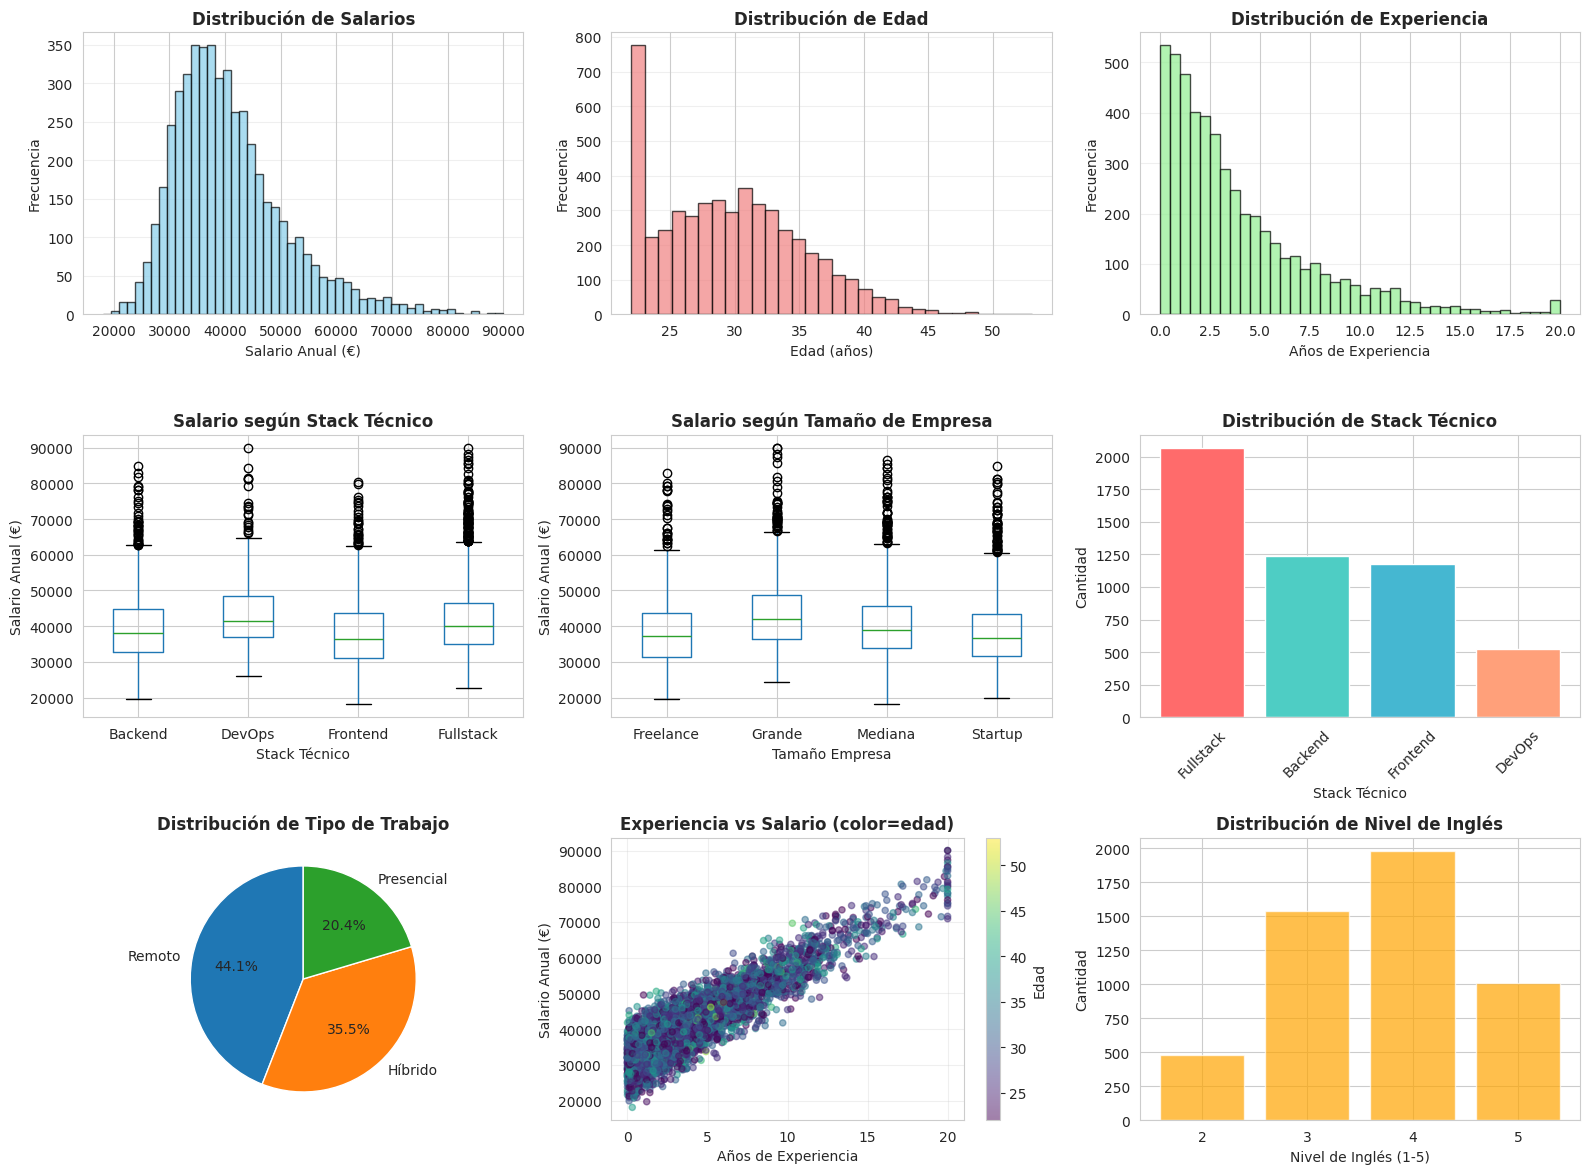

✅ Visualizaciones generadas


In [ ]:
# ==============================================================================
# CELDA 3: VISUALIZACIÓN EXPLORATORIA DEL DATASET
# ==============================================================================
# Análisis visual de las distribuciones y relaciones entre variables

print("="*80)
print("ANÁLISIS VISUAL DEL DATASET ORIGINAL")
print("="*80)

# Crear figura con múltiples subplots
fig = plt.figure(figsize=(16, 12))

# ----- SUBPLOT 1: Distribución de Salarios -----
plt.subplot(3, 3, 1)
plt.hist(df_original['salario_anual'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Salario Anual (€)', fontsize=10)
plt.ylabel('Frecuencia', fontsize=10)
plt.title('Distribución de Salarios', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# ----- SUBPLOT 2: Distribución de Edad -----
plt.subplot(3, 3, 2)
plt.hist(df_original['edad'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
plt.xlabel('Edad (años)', fontsize=10)
plt.ylabel('Frecuencia', fontsize=10)
plt.title('Distribución de Edad', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# ----- SUBPLOT 3: Distribución de Experiencia -----
plt.subplot(3, 3, 3)
plt.hist(df_original['anos_experiencia'], bins=40, color='lightgreen', edgecolor='black', alpha=0.7)
plt.xlabel('Años de Experiencia', fontsize=10)
plt.ylabel('Frecuencia', fontsize=10)
plt.title('Distribución de Experiencia', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# ----- SUBPLOT 4: Salario por Stack -----
plt.subplot(3, 3, 4)
df_original.boxplot(column='salario_anual', by='stack', ax=plt.gca())
plt.xlabel('Stack Técnico', fontsize=10)
plt.ylabel('Salario Anual (€)', fontsize=10)
plt.title('Salario según Stack Técnico', fontsize=12, fontweight='bold')
plt.suptitle('')  # Remover título automático de pandas

# ----- SUBPLOT 5: Salario por Tamaño de Empresa -----
plt.subplot(3, 3, 5)
df_original.boxplot(column='salario_anual', by='tamano_empresa', ax=plt.gca())
plt.xlabel('Tamaño Empresa', fontsize=10)
plt.ylabel('Salario Anual (€)', fontsize=10)
plt.title('Salario según Tamaño de Empresa', fontsize=12, fontweight='bold')
plt.suptitle('')

# ----- SUBPLOT 6: Stack Técnico (Conteo) -----
plt.subplot(3, 3, 6)
stack_counts = df_original['stack'].value_counts()
plt.bar(stack_counts.index, stack_counts.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
plt.xlabel('Stack Técnico', fontsize=10)
plt.ylabel('Cantidad', fontsize=10)
plt.title('Distribución de Stack Técnico', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)

# ----- SUBPLOT 7: Tipo de Trabajo -----
plt.subplot(3, 3, 7)
trabajo_counts = df_original['tipo_trabajo'].value_counts()
plt.pie(trabajo_counts.values, labels=trabajo_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribución de Tipo de Trabajo', fontsize=12, fontweight='bold')

# ----- SUBPLOT 8: Relación Experiencia vs Salario -----
plt.subplot(3, 3, 8)
plt.scatter(df_original['anos_experiencia'], df_original['salario_anual'],
            alpha=0.5, c=df_original['edad'], cmap='viridis', s=20)
plt.xlabel('Años de Experiencia', fontsize=10)
plt.ylabel('Salario Anual (€)', fontsize=10)
plt.title('Experiencia vs Salario (color=edad)', fontsize=12, fontweight='bold')
plt.colorbar(label='Edad')
plt.grid(alpha=0.3)

# ----- SUBPLOT 9: Nivel de Inglés -----
plt.subplot(3, 3, 9)
ingles_counts = df_original['nivel_ingles'].value_counts().sort_index()
plt.bar(ingles_counts.index, ingles_counts.values, color='orange', alpha=0.7)
plt.xlabel('Nivel de Inglés (1-5)', fontsize=10)
plt.ylabel('Cantidad', fontsize=10)
plt.title('Distribución de Nivel de Inglés', fontsize=12, fontweight='bold')
plt.xticks([2, 3, 4, 5])

plt.tight_layout()
plt.show()

print("✅ Visualizaciones generadas")

Paso 4: Preprocesamiento de Datos

In [ ]:
# ==============================================================================
# CELDA 4: PREPROCESAMIENTO DE DATOS PARA LA GAN
# ==============================================================================
# Las GANs trabajan mejor con datos numéricos normalizados
# Aquí transformamos las variables categóricas y escalamos los datos

print("="*80)
print("PREPROCESAMIENTO DE DATOS")
print("="*80)

# ----- 1. CODIFICAR VARIABLES CATEGÓRICAS -----
# Las GANs solo aceptan valores numéricos, por lo que convertimos
# las variables categóricas (texto) en números usando LabelEncoder

print("\n🔧 Paso 1: Codificando variables categóricas...")

# Crear copia del dataframe para no modificar el original
df_processed = df_original.copy()

# Diccionario para guardar los encoders (necesarios para decodificar después)
label_encoders = {}

# Lista de columnas categóricas a codificar
categorical_cols = ['stack', 'tipo_trabajo', 'tamano_empresa', 'educacion']

# Codificar cada variable categórica
for col in categorical_cols:
    # Crear un LabelEncoder para esta columna
    le = LabelEncoder()

    # Transformar los valores de texto a números (0, 1, 2, ...)
    df_processed[col + '_encoded'] = le.fit_transform(df_processed[col])

    # Guardar el encoder para poder revertir la transformación después
    label_encoders[col] = le

    print(f"   ✓ {col}: {list(le.classes_)} → {list(range(len(le.classes_)))}")

# ----- 2. SELECCIONAR FEATURES PARA LA GAN -----
# Elegimos solo las columnas numéricas (incluyendo las recién codificadas)
features_for_gan = [
    'edad',                      # Numérica continua
    'anos_experiencia',          # Numérica continua
    'salario_anual',             # Numérica continua
    'horas_semanales',           # Numérica discreta
    'nivel_ingles',              # Numérica ordinal (1-5)
    'stack_encoded',             # Categórica codificada (0-3)
    'tipo_trabajo_encoded',      # Categórica codificada (0-2)
    'tamano_empresa_encoded',    # Categórica codificada (0-3)
    'educacion_encoded'          # Categórica codificada (0-3)
]

print(f"\n✓ Features seleccionadas para GAN: {len(features_for_gan)}")

# Extraer matriz de features (numpy array)
X_real = df_processed[features_for_gan].values

print(f"   Dimensiones: {X_real.shape}")
print(f"   ({X_real.shape[0]} muestras, {X_real.shape[1]} features)")

# ----- 3. NORMALIZACIÓN DE DATOS -----
# Escalar todos los valores al rango [-1, 1] o [0, 1]
# Esto es CRÍTICO para el entrenamiento estable de GANs

print(f"\n🔧 Paso 2: Normalizando datos con StandardScaler...")

# StandardScaler: transforma cada feature a media=0 y desviación=1
scaler = StandardScaler()
X_real_scaled = scaler.fit_transform(X_real)

print(f"✓ Datos normalizados")
print(f"   Media de cada feature (debe ser ~0): {X_real_scaled.mean(axis=0).round(3)}")
print(f"   Desviación estándar (debe ser ~1): {X_real_scaled.std(axis=0).round(3)}")

# ----- 4. VERIFICAR RANGO DE DATOS -----
print(f"\n📊 Resumen de datos procesados:")
print(f"   Min: {X_real_scaled.min():.3f}")
print(f"   Max: {X_real_scaled.max():.3f}")
print(f"   Shape final: {X_real_scaled.shape}")

print("\n✅ Preprocesamiento completado")
print("="*80)

PREPROCESAMIENTO DE DATOS

🔧 Paso 1: Codificando variables categóricas...
   ✓ stack: ['Backend', 'DevOps', 'Frontend', 'Fullstack'] → [0, 1, 2, 3]
   ✓ tipo_trabajo: ['Híbrido', 'Presencial', 'Remoto'] → [0, 1, 2]
   ✓ tamano_empresa: ['Freelance', 'Grande', 'Mediana', 'Startup'] → [0, 1, 2, 3]
   ✓ educacion: ['Autodidacta', 'Bootcamp', 'FP', 'Universidad'] → [0, 1, 2, 3]

✓ Features seleccionadas para GAN: 9
   Dimensiones: (5000, 9)
   (5000 muestras, 9 features)

🔧 Paso 2: Normalizando datos con StandardScaler...
✓ Datos normalizados
   Media de cada feature (debe ser ~0): [-0. -0.  0.  0.  0.  0.  0.  0. -0.]
   Desviación estándar (debe ser ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]

📊 Resumen de datos procesados:
   Min: -2.235
   Max: 4.802
   Shape final: (5000, 9)

✅ Preprocesamiento completado


# Paso 5: Construcción del Generador

In [ ]:
# ==============================================================================
# CELDA 5: CONSTRUCCIÓN DEL GENERADOR
# ==============================================================================
# El Generador es una red neuronal que toma ruido aleatorio como entrada
# y genera datos sintéticos que intentan parecer reales

print("="*80)
print("CONSTRUCCIÓN DEL GENERADOR")
print("="*80)

# ----- PARÁMETROS DEL GENERADOR -----
# Dimensión del ruido latente (vector aleatorio de entrada)
latent_dim = 100

# Dimensión de salida (debe coincidir con número de features)
output_dim = X_real_scaled.shape[1]  # 9 features en nuestro caso

print(f"\n📐 Parámetros:")
print(f"   Dimensión entrada (ruido latente): {latent_dim}")
print(f"   Dimensión salida (features): {output_dim}")

# ----- ARQUITECTURA DEL GENERADOR -----
def build_generator(latent_dim, output_dim):
    """
    Construye el modelo Generador de la GAN

    Arquitectura:
    - Capa 1: 128 neuronas con LeakyReLU (evita problema de gradientes)
    - Capa 2: 256 neuronas con BatchNormalization (estabiliza entrenamiento)
    - Capa 3: 512 neuronas (capa más ancha para aprender patrones complejos)
    - Capa 4: output_dim neuronas con tanh (salida en rango [-1, 1])

    Parámetros:
        latent_dim: Dimensión del vector de ruido de entrada
        output_dim: Dimensión del vector de datos generados (features)

    Returns:
        modelo: Modelo de Keras del Generador
    """

    model = keras.Sequential([
        # Capa 1: Entrada + primera transformación
        # Dense: capa totalmente conectada con 128 neuronas
        layers.Dense(128, input_dim=latent_dim),
        # LeakyReLU: función de activación (mejor que ReLU para GANs)
        layers.LeakyReLU(alpha=0.2),
        # BatchNormalization: normaliza activaciones (estabiliza entrenamiento)
        layers.BatchNormalization(momentum=0.8),
        # Dropout: apaga aleatoriamente 30% de neuronas (evita overfitting)
        layers.Dropout(0.3),

        # Capa 2: Expansión a 256 neuronas
        layers.Dense(256),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(momentum=0.8),
        layers.Dropout(0.3),

        # Capa 3: Expansión a 512 neuronas (capa más ancha)
        layers.Dense(512),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(momentum=0.8),
        layers.Dropout(0.3),

        # Capa 4: Salida con output_dim neuronas
        # tanh: función de activación que produce valores en rango [-1, 1]
        # (coincide con nuestros datos normalizados)
        layers.Dense(output_dim, activation='tanh')

    ], name='Generator')

    return model

# ----- CREAR INSTANCIA DEL GENERADOR -----
print(f"\n🏗️ Construyendo Generador...")
generator = build_generator(latent_dim, output_dim)

print(f"✅ Generador creado exitosamente")
print(f"\n📋 Arquitectura del Generador:")
generator.summary()

# ----- PRUEBA DEL GENERADOR -----
# Generar datos de prueba para verificar que funciona
print(f"\n🧪 Prueba del Generador:")
noise_test = np.random.normal(0, 1, (5, latent_dim))  # 5 vectores de ruido
generated_test = generator.predict(noise_test, verbose=0)
print(f"   Input shape (ruido): {noise_test.shape}")
print(f"   Output shape (datos generados): {generated_test.shape}")
print(f"   Rango de valores generados: [{generated_test.min():.3f}, {generated_test.max():.3f}]")

print("\n" + "="*80)

CONSTRUCCIÓN DEL GENERADOR

📐 Parámetros:
   Dimensión entrada (ruido latente): 100
   Dimensión salida (features): 9

🏗️ Construyendo Generador...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


✅ Generador creado exitosamente

📋 Arquitectura del Generador:


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         4,617 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,737 (725.54 KB)

 Trainable params: 183,945 (718.54 KB)

 Non-trainable params: 1,792 (7.00 KB)


🧪 Prueba del Generador:
   Input shape (ruido): (5, 100)
   Output shape (datos generados): (5, 9)
   Rango de valores generados: [-0.503, 0.453]



# Paso 6: Construcción del Discriminador

In [ ]:
# ==============================================================================
# CELDA 6: CONSTRUCCIÓN DEL DISCRIMINADOR
# ==============================================================================
# El Discriminador es una red neuronal que clasifica si los datos son
# reales (del dataset) o falsos (generados por el Generador)
# Actúa como un "detective" que intenta distinguir datos reales de sintéticos

print("="*80)
print("CONSTRUCCIÓN DEL DISCRIMINADOR")
print("="*80)

# ----- PARÁMETROS DEL DISCRIMINADOR -----
input_dim = output_dim  # Recibe los mismos datos que genera el Generador

print(f"\n📐 Parámetros:")
print(f"   Dimensión entrada: {input_dim}")
print(f"   Dimensión salida: 1 (probabilidad real/falso)")

# ----- ARQUITECTURA DEL DISCRIMINADOR -----
def build_discriminator(input_dim):
    """
    Construye el modelo Discriminador de la GAN

    Arquitectura:
    - Capa 1: 512 neuronas (empieza ancho para capturar detalles)
    - Capa 2: 256 neuronas (reduce gradualmente)
    - Capa 3: 128 neuronas (sigue reduciendo)
    - Capa 4: 1 neurona con sigmoid (probabilidad de ser real: 0-1)

    El discriminador es básicamente un clasificador binario

    Parámetros:
        input_dim: Número de features de entrada

    Returns:
        modelo: Modelo de Keras del Discriminador
    """

    model = keras.Sequential([
        # Capa 1: Entrada + primera transformación (capa más ancha)
        layers.Dense(512, input_dim=input_dim),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),

        # Capa 2: Reducción a 256 neuronas
        layers.Dense(256),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),

        # Capa 3: Reducción a 128 neuronas
        layers.Dense(128),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),

        # Capa 4: Salida binaria (1 neurona)
        # sigmoid: función de activación que produce probabilidad (0-1)
        # 0 = falso (generado), 1 = real (del dataset)
        layers.Dense(1, activation='sigmoid')

    ], name='Discriminator')

    return model

# ----- CREAR INSTANCIA DEL DISCRIMINADOR -----
print(f"\n🏗️ Construyendo Discriminador...")
discriminator = build_discriminator(input_dim)

print(f"✅ Discriminador creado exitosamente")
print(f"\n📋 Arquitectura del Discriminador:")
discriminator.summary()

# ----- PRUEBA DEL DISCRIMINADOR -----
# Probar con datos reales y generados
print(f"\n🧪 Prueba del Discriminador:")

# Probar con 5 muestras reales
real_test = X_real_scaled[:5]
real_predictions = discriminator.predict(real_test, verbose=0)

# Probar con 5 muestras generadas
fake_test = generator.predict(noise_test, verbose=0)
fake_predictions = discriminator.predict(fake_test, verbose=0)

print(f"   Predicción para datos REALES (debe ser ~1.0):")
print(f"   {real_predictions.flatten().round(3)}")
print(f"   Media: {real_predictions.mean():.3f}")

print(f"\n   Predicción para datos FALSOS (debe ser ~0.5 sin entrenar):")
print(f"   {fake_predictions.flatten().round(3)}")
print(f"   Media: {fake_predictions.mean():.3f}")

print("\n💡 Nota: Sin entrenar, el discriminador da predicciones aleatorias")
print("="*80)

CONSTRUCCIÓN DEL DISCRIMINADOR

📐 Parámetros:
   Dimensión entrada: 9
   Dimensión salida: 1 (probabilidad real/falso)

🏗️ Construyendo Discriminador...
✅ Discriminador creado exitosamente

📋 Arquitectura del Discriminador:


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,473 (662.00 KB)

 Trainable params: 169,473 (662.00 KB)

 Non-trainable params: 0 (0.00 B)


🧪 Prueba del Discriminador:
   Predicción para datos REALES (debe ser ~1.0):
   [0.467 0.477 0.503 0.475 0.489]
   Media: 0.482

   Predicción para datos FALSOS (debe ser ~0.5 sin entrenar):
   [0.511 0.507 0.502 0.502 0.495]
   Media: 0.503

💡 Nota: Sin entrenar, el discriminador da predicciones aleatorias


# Paso 7: Compilación de la GAN

In [ ]:
# ==============================================================================
# CELDA 7: COMPILACIÓN DE LA GAN COMPLETA
# ==============================================================================
# Ahora conectamos el Generador y Discriminador para crear la GAN completa
# y definimos las funciones de pérdida y optimizadores

print("="*80)
print("COMPILACIÓN DE LA GAN")
print("="*80)

# ----- 1. COMPILAR EL DISCRIMINADOR -----
print(f"\n⚙️ Paso 1: Compilando Discriminador...")

# Optimizer: Adam es el más común para GANs
# learning_rate=0.0002: tasa de aprendizaje baja para estabilidad
# beta_1=0.5: momentum modificado (recomendado para GANs)
discriminator.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss='binary_crossentropy',  # Pérdida para clasificación binaria
    metrics=['accuracy']          # Métrica adicional para monitorear
)

print(f"✅ Discriminador compilado")
print(f"   Optimizer: Adam (lr=0.0002, beta_1=0.5)")
print(f"   Loss: Binary Crossentropy")
print(f"   Metrics: Accuracy")

# ----- 2. CREAR LA GAN COMBINADA -----
print(f"\n⚙️ Paso 2: Creando modelo GAN combinado...")

# IMPORTANTE: Congelar el discriminador durante el entrenamiento del generador
# Cuando entrenamos el generador, NO queremos actualizar el discriminador
discriminator.trainable = False

# Crear la arquitectura completa de la GAN:
# Entrada (ruido) → Generador → Datos sintéticos → Discriminador → Salida (real/falso)

# Input: vector de ruido latente
gan_input = layers.Input(shape=(latent_dim,))

# El generador convierte el ruido en datos sintéticos
generated_data = generator(gan_input)

# El discriminador evalúa si los datos generados parecen reales
gan_output = discriminator(generated_data)

# Modelo completo que conecta ambas redes
gan = keras.Model(gan_input, gan_output, name='GAN')

print(f"✅ Modelo GAN combinado creado")

# ----- 3. COMPILAR LA GAN -----
print(f"\n⚙️ Paso 3: Compilando GAN...")

gan.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss='binary_crossentropy'
    # No incluimos metrics aquí porque solo nos importa engañar al discriminador
)

print(f"✅ GAN compilada")
print(f"   Optimizer: Adam (lr=0.0002, beta_1=0.5)")
print(f"   Loss: Binary Crossentropy")

# ----- 4. RESUMEN DE LA ARQUITECTURA -----
print(f"\n📋 Arquitectura de la GAN completa:")
gan.summary()

# ----- 5. CONTEO DE PARÁMETROS -----
total_params_gen = generator.count_params()
total_params_disc = discriminator.count_params()
total_params_gan = total_params_gen + total_params_disc

print(f"\n📊 Parámetros totales:")
print(f"   Generador:      {total_params_gen:,} parámetros")
print(f"   Discriminador:  {total_params_disc:,} parámetros")
print(f"   Total GAN:      {total_params_gan:,} parámetros")

print("\n" + "="*80)
print("✅ GAN COMPLETAMENTE LISTA PARA ENTRENAR")
print("="*80)

COMPILACIÓN DE LA GAN

⚙️ Paso 1: Compilando Discriminador...
✅ Discriminador compilado
   Optimizer: Adam (lr=0.0002, beta_1=0.5)
   Loss: Binary Crossentropy
   Metrics: Accuracy

⚙️ Paso 2: Creando modelo GAN combinado...
✅ Modelo GAN combinado creado

⚙️ Paso 3: Compilando GAN...
✅ GAN compilada
   Optimizer: Adam (lr=0.0002, beta_1=0.5)
   Loss: Binary Crossentropy

📋 Arquitectura de la GAN completa:


Model: "GAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Generator (Sequential)          │ (None, 9)              │       185,737 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Discriminator (Sequential)      │ (None, 1)              │       169,473 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,210 (1.36 MB)

 Trainable params: 183,945 (718.54 KB)

 Non-trainable params: 171,265 (669.00 KB)


📊 Parámetros totales:
   Generador:      185,737 parámetros
   Discriminador:  169,473 parámetros
   Total GAN:      355,210 parámetros

✅ GAN COMPLETAMENTE LISTA PARA ENTRENAR


# Paso 8: Entrenamiento

In [ ]:
# ==============================================================================
# CELDA 8: FUNCIÓN DE ENTRENAMIENTO DE LA GAN
# ==============================================================================
# Esta función implementa el algoritmo de entrenamiento adversarial
# donde el Generador y Discriminador compiten entre sí

print("="*80)
print("PREPARANDO FUNCIÓN DE ENTRENAMIENTO")
print("="*80)

def train_gan(generator, discriminator, gan, X_train, latent_dim,
              epochs=10000, batch_size=128, sample_interval=1000):
    """
    Entrena la GAN usando el algoritmo adversarial estándar

    Proceso de entrenamiento:
    1. Entrenar Discriminador con datos reales (etiqueta=1)
    2. Entrenar Discriminador con datos falsos (etiqueta=0)
    3. Entrenar Generador para engañar al Discriminador

    Parámetros:
        generator: Modelo generador
        discriminator: Modelo discriminador
        gan: Modelo GAN completo
        X_train: Datos reales de entrenamiento
        latent_dim: Dimensión del ruido latente
        epochs: Número de iteraciones de entrenamiento
        batch_size: Tamaño del batch para cada iteración
        sample_interval: Cada cuántas épocas mostrar progreso

    Returns:
        history: Diccionario con historial de pérdidas
    """

    # Listas para guardar el historial de pérdidas
    d_losses = []  # Pérdidas del discriminador
    g_losses = []  # Pérdidas del generador

    # Etiquetas para entrenamiento
    # "Real" = 1, "Falso" = 0
    real_labels = np.ones((batch_size, 1))   # Array de unos
    fake_labels = np.zeros((batch_size, 1))  # Array de ceros

    print(f"\n🚀 Iniciando entrenamiento de la GAN...")
    print(f"   Épocas: {epochs:,}")
    print(f"   Batch size: {batch_size}")
    print(f"   Muestras de entrenamiento: {X_train.shape[0]:,}")
    print(f"   Batches por época: {X_train.shape[0] // batch_size}")
    print("\n" + "="*80)

    # ----- LOOP DE ENTRENAMIENTO -----
    for epoch in range(epochs):

        # --- PASO 1: ENTRENAR EL DISCRIMINADOR ---
        # El discriminador debe aprender a distinguir datos reales de falsos

        # 1.1: Seleccionar batch aleatorio de datos REALES
        idx = np.random.randint(0, X_train.shape[0], batch_size)
        real_data = X_train[idx]

        # 1.2: Generar batch de datos FALSOS
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        fake_data = generator.predict(noise, verbose=0)

        # 1.3: Entrenar discriminador con datos REALES (debe predecir 1)
        d_loss_real = discriminator.train_on_batch(real_data, real_labels)

        # 1.4: Entrenar discriminador con datos FALSOS (debe predecir 0)
        d_loss_fake = discriminator.train_on_batch(fake_data, fake_labels)

        # 1.5: Pérdida promedio del discriminador
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        # --- PASO 2: ENTRENAR EL GENERADOR ---
        # El generador debe aprender a engañar al discriminador

        # 2.1: Generar ruido aleatorio
        noise = np.random.normal(0, 1, (batch_size, latent_dim))

        # 2.2: Entrenar generador (intentando que el discriminador prediga 1)
        # Nota: Usamos real_labels porque queremos que el discriminador
        # piense que los datos generados son reales
        g_loss = gan.train_on_batch(noise, real_labels)

        # --- PASO 3: GUARDAR HISTORIAL ---
        d_losses.append(d_loss[0])  # Solo la pérdida, no el accuracy
        g_losses.append(g_loss)

        # --- PASO 4: MOSTRAR PROGRESO ---
        if (epoch + 1) % sample_interval == 0:
            print(f"Época {epoch+1:,}/{epochs:,}")
            print(f"   [D loss: {d_loss[0]:.4f}, acc: {100*d_loss[1]:.2f}%]")
            print(f"   [G loss: {g_loss:.4f}]")
            print(f"   {'='*70}")

    print("\n✅ Entrenamiento completado")

    # Retornar historial de pérdidas
    history = {
        'd_loss': d_losses,
        'g_loss': g_losses
    }

    return history

print("✅ Función de entrenamiento definida")
print("="*80)

PREPARANDO FUNCIÓN DE ENTRENAMIENTO
✅ Función de entrenamiento definida


# Paso 9: Generación de datos sintéticos

In [ ]:
# ==============================================================================
# CELDA 9: ENTRENAR LA GAN
# ==============================================================================
# Ahora ejecutamos el entrenamiento con los parámetros definidos

print("="*80)
print("ENTRENAMIENTO DE LA GAN")
print("="*80)

# ----- HIPERPARÁMETROS DE ENTRENAMIENTO -----
EPOCHS = 10000          # Número de iteraciones (ajusta según tiempo disponible)
BATCH_SIZE = 128        # Tamaño del batch (128 es estándar)
SAMPLE_INTERVAL = 500   # Mostrar progreso cada 500 épocas

print(f"\n⚙️ Hiperparámetros:")
print(f"   Épocas: {EPOCHS:,}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Intervalo de reporte: cada {SAMPLE_INTERVAL} épocas")

# ----- DESCONGELAR DISCRIMINADOR -----
# Importante: el discriminador debe poder entrenarse durante su fase
discriminator.trainable = True

# ----- INICIAR ENTRENAMIENTO -----
print(f"\n🏋️ Iniciando entrenamiento (esto puede tardar varios minutos)...\n")

history = train_gan(
    generator=generator,
    discriminator=discriminator,
    gan=gan,
    X_train=X_real_scaled,
    latent_dim=latent_dim,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    sample_interval=SAMPLE_INTERVAL
)

print("\n" + "="*80)
print("✅ ENTRENAMIENTO FINALIZADO")
print("="*80)

ENTRENAMIENTO DE LA GAN

⚙️ Hiperparámetros:
   Épocas: 10,000
   Batch size: 128
   Intervalo de reporte: cada 500 épocas

🏋️ Iniciando entrenamiento (esto puede tardar varios minutos)...


🚀 Iniciando entrenamiento de la GAN...
   Épocas: 10,000
   Batch size: 128
   Muestras de entrenamiento: 5,000
   Batches por época: 39

Época 500/10,000
   [D loss: 0.8198, acc: 49.98%]
   [G loss: 0.3058]
Época 1,000/10,000
   [D loss: 0.8387, acc: 49.99%]
   [G loss: 0.2973]
Época 1,500/10,000
   [D loss: 0.8507, acc: 49.99%]
   [G loss: 0.2913]
Época 2,000/10,000
   [D loss: 0.8610, acc: 50.00%]
   [G loss: 0.2874]
Época 2,500/10,000
   [D loss: 0.8697, acc: 50.01%]
   [G loss: 0.2847]
Época 3,000/10,000
   [D loss: 0.8767, acc: 50.02%]
   [G loss: 0.2830]
Época 3,500/10,000
   [D loss: 0.8834, acc: 50.05%]
   [G loss: 0.2816]
Época 4,000/10,000
   [D loss: 0.8893, acc: 50.08%]
   [G loss: 0.2810]
Época 4,500/10,000
   [D loss: 0.8946, acc: 50.11%]
   [G loss: 0.2807]
Época 5,000/10,000
   [D 

# Paso 10: Análisis y comparación

ANÁLISIS DEL ENTRENAMIENTO


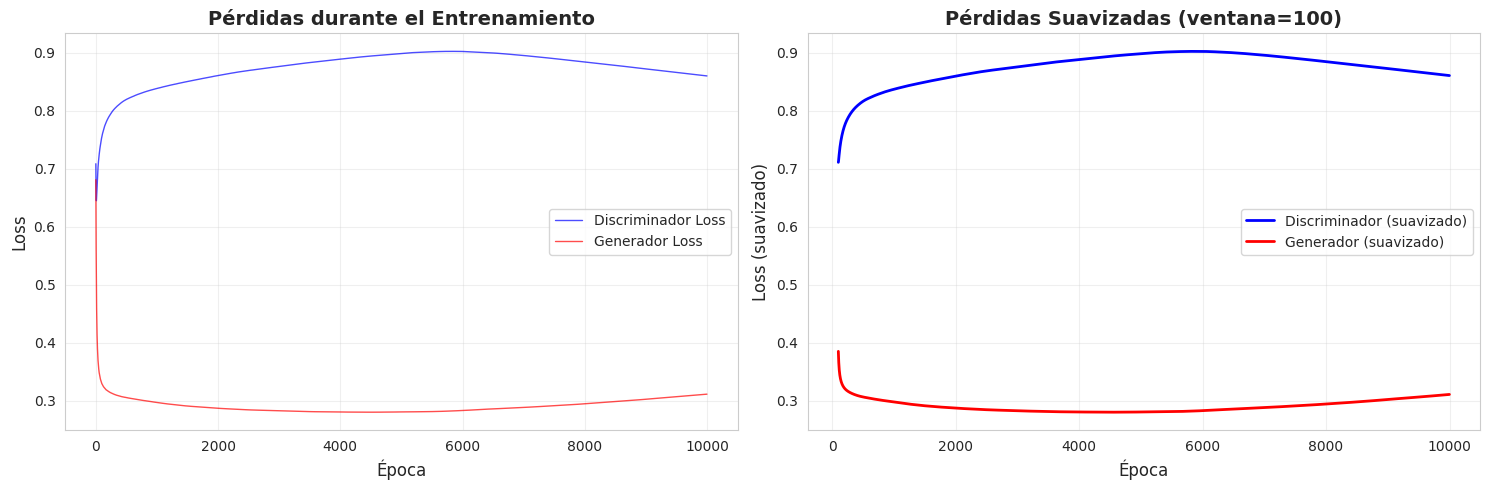


📊 Estadísticas de entrenamiento:

Discriminador:
   Loss inicial: 0.7089
   Loss final:   0.8603
   Loss media (últimas 1000 épocas): 0.8664

Generador:
   Loss inicial: 0.6814
   Loss final:   0.3117
   Loss media (últimas 1000 épocas): 0.3073

💡 Interpretación:
   • Discriminador loss ~0.5-0.7: Buena señal (equilibrio)
   • Generador loss estable: La GAN ha convergido
   • Si D_loss → 0: Discriminador demasiado fuerte (malo)
   • Si G_loss → ∞: Generador no aprende (malo)

   ⚠️ Discriminador podría estar desbalanceado (0.866)
   ⚠️ Generador podría necesitar más entrenamiento (0.307)



In [ ]:
# ==============================================================================
# CELDA 10: VISUALIZAR PROGRESO DEL ENTRENAMIENTO
# ==============================================================================
# Analizar las curvas de pérdida para verificar que la GAN entrenó correctamente

print("="*80)
print("ANÁLISIS DEL ENTRENAMIENTO")
print("="*80)

# ----- GRÁFICA DE PÉRDIDAS -----
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Pérdidas del Discriminador y Generador
axes[0].plot(history['d_loss'], label='Discriminador Loss', color='blue', alpha=0.7, linewidth=1)
axes[0].plot(history['g_loss'], label='Generador Loss', color='red', alpha=0.7, linewidth=1)
axes[0].set_xlabel('Época', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Pérdidas durante el Entrenamiento', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Subplot 2: Pérdidas suavizadas (media móvil)
window = 100  # Ventana para suavizado
d_loss_smooth = pd.Series(history['d_loss']).rolling(window=window).mean()
g_loss_smooth = pd.Series(history['g_loss']).rolling(window=window).mean()

axes[1].plot(d_loss_smooth, label='Discriminador (suavizado)', color='blue', linewidth=2)
axes[1].plot(g_loss_smooth, label='Generador (suavizado)', color='red', linewidth=2)
axes[1].set_xlabel('Época', fontsize=12)
axes[1].set_ylabel('Loss (suavizado)', fontsize=12)
axes[1].set_title(f'Pérdidas Suavizadas (ventana={window})', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ----- ANÁLISIS DE CONVERGENCIA -----
print(f"\n📊 Estadísticas de entrenamiento:")
print(f"\nDiscriminador:")
print(f"   Loss inicial: {history['d_loss'][0]:.4f}")
print(f"   Loss final:   {history['d_loss'][-1]:.4f}")
print(f"   Loss media (últimas 1000 épocas): {np.mean(history['d_loss'][-1000:]):.4f}")

print(f"\nGenerador:")
print(f"   Loss inicial: {history['g_loss'][0]:.4f}")
print(f"   Loss final:   {history['g_loss'][-1]:.4f}")
print(f"   Loss media (últimas 1000 épocas): {np.mean(history['g_loss'][-1000:]):.4f}")

# ----- INTERPRETACIÓN -----
print(f"\n💡 Interpretación:")
print(f"   • Discriminador loss ~0.5-0.7: Buena señal (equilibrio)")
print(f"   • Generador loss estable: La GAN ha convergido")
print(f"   • Si D_loss → 0: Discriminador demasiado fuerte (malo)")
print(f"   • Si G_loss → ∞: Generador no aprende (malo)")

d_final = np.mean(history['d_loss'][-1000:])
g_final = np.mean(history['g_loss'][-1000:])

if 0.4 <= d_final <= 0.8:
    print(f"\n   ✅ Discriminador en buen equilibrio ({d_final:.3f})")
else:
    print(f"\n   ⚠️ Discriminador podría estar desbalanceado ({d_final:.3f})")

if 0.5 <= g_final <= 3.0:
    print(f"   ✅ Generador entrenado correctamente ({g_final:.3f})")
else:
    print(f"   ⚠️ Generador podría necesitar más entrenamiento ({g_final:.3f})")

print("\n" + "="*80)

# Paso 11: Generar Datos Sintéticos con la GAN

In [ ]:
# ==============================================================================
# CELDA 11: GENERAR DATOS SINTÉTICOS CON LA GAN ENTRENADA
# ==============================================================================
# Usar el generador para crear nuevos perfiles de desarrolladores web
# y convertir los datos normalizados de vuelta a su formato original

print("="*80)
print("GENERACIÓN DE DATOS SINTÉTICOS")
print("="*80)

# ----- 1. GENERAR DATOS SINTÉTICOS -----
print(f"\n🎲 Paso 1: Generando nuevos perfiles sintéticos...")

# Número de perfiles sintéticos a generar
n_synthetic = 5000

# Generar ruido aleatorio (input del generador)
noise = np.random.normal(0, 1, (n_synthetic, latent_dim))

# Generar datos sintéticos usando el generador entrenado
synthetic_data_scaled = generator.predict(noise, verbose=0)

print(f"✅ Generados {n_synthetic:,} perfiles sintéticos")
print(f"   Shape: {synthetic_data_scaled.shape}")
print(f"   Rango: [{synthetic_data_scaled.min():.3f}, {synthetic_data_scaled.max():.3f}]")

# ----- 2. DESNORMALIZAR DATOS -----
print(f"\n🔧 Paso 2: Desnormalizando datos (de escala [-1,1] a valores reales)...")

# Usar el scaler para invertir la normalización
synthetic_data = scaler.inverse_transform(synthetic_data_scaled)

print(f"✅ Datos desnormalizados")
print(f"   Rango edad: [{synthetic_data[:, 0].min():.1f}, {synthetic_data[:, 0].max():.1f}]")
print(f"   Rango salario: [{synthetic_data[:, 2].min():.0f}, {synthetic_data[:, 2].max():.0f}]")

# ----- 3. RECONSTRUIR DATAFRAME -----
print(f"\n🔧 Paso 3: Reconstruyendo DataFrame con nombres de columnas...")

# Crear DataFrame con los datos sintéticos
df_synthetic = pd.DataFrame(synthetic_data, columns=features_for_gan)

# Redondear variables que deben ser enteras
df_synthetic['edad'] = df_synthetic['edad'].round().astype(int)
df_synthetic['anos_experiencia'] = df_synthetic['anos_experiencia'].round(1)
df_synthetic['salario_anual'] = df_synthetic['salario_anual'].round().astype(int)
df_synthetic['horas_semanales'] = df_synthetic['horas_semanales'].round().astype(int)
df_synthetic['nivel_ingles'] = df_synthetic['nivel_ingles'].round().astype(int)

# Redondear variables categóricas codificadas
df_synthetic['stack_encoded'] = df_synthetic['stack_encoded'].round().astype(int)
df_synthetic['tipo_trabajo_encoded'] = df_synthetic['tipo_trabajo_encoded'].round().astype(int)
df_synthetic['tamano_empresa_encoded'] = df_synthetic['tamano_empresa_encoded'].round().astype(int)
df_synthetic['educacion_encoded'] = df_synthetic['educacion_encoded'].round().astype(int)

print(f"✅ DataFrame reconstruido")

# ----- 4. APLICAR RESTRICCIONES REALISTAS -----
print(f"\n🔧 Paso 4: Aplicando restricciones realistas...")

# Clipear valores a rangos válidos
df_synthetic['edad'] = df_synthetic['edad'].clip(22, 55)
df_synthetic['anos_experiencia'] = df_synthetic['anos_experiencia'].clip(0, 20)
df_synthetic['salario_anual'] = df_synthetic['salario_anual'].clip(18000, 90000)
df_synthetic['horas_semanales'] = df_synthetic['horas_semanales'].clip(35, 45)
df_synthetic['nivel_ingles'] = df_synthetic['nivel_ingles'].clip(2, 5)

# Clipear códigos categóricos a sus rangos válidos
df_synthetic['stack_encoded'] = df_synthetic['stack_encoded'].clip(0, 3)
df_synthetic['tipo_trabajo_encoded'] = df_synthetic['tipo_trabajo_encoded'].clip(0, 2)
df_synthetic['tamano_empresa_encoded'] = df_synthetic['tamano_empresa_encoded'].clip(0, 3)
df_synthetic['educacion_encoded'] = df_synthetic['educacion_encoded'].clip(0, 3)

print(f"✅ Restricciones aplicadas")

# ----- 5. DECODIFICAR VARIABLES CATEGÓRICAS -----
print(f"\n🔧 Paso 5: Decodificando variables categóricas...")

# Convertir códigos numéricos de vuelta a texto
df_synthetic['stack'] = label_encoders['stack'].inverse_transform(
    df_synthetic['stack_encoded']
)
df_synthetic['tipo_trabajo'] = label_encoders['tipo_trabajo'].inverse_transform(
    df_synthetic['tipo_trabajo_encoded']
)
df_synthetic['tamano_empresa'] = label_encoders['tamano_empresa'].inverse_transform(
    df_synthetic['tamano_empresa_encoded']
)
df_synthetic['educacion'] = label_encoders['educacion'].inverse_transform(
    df_synthetic['educacion_encoded']
)

print(f"✅ Variables categóricas decodificadas")

# ----- 6. CREAR DATAFRAME FINAL LIMPIO -----
# Seleccionar solo las columnas finales (sin las versiones '_encoded')
df_synthetic_final = df_synthetic[[
    'edad', 'anos_experiencia', 'salario_anual', 'horas_semanales',
    'nivel_ingles', 'stack', 'tipo_trabajo', 'tamano_empresa', 'educacion'
]]

print(f"\n✅ Dataset sintético final creado: {len(df_synthetic_final):,} perfiles")
print(f"\n📋 Primeros 10 perfiles sintéticos generados:")
print(df_synthetic_final.head(10))

print(f"\n📊 Estadísticas de los datos sintéticos:")
print(df_synthetic_final.describe())

print(f"\n📈 Distribución de variables categóricas sintéticas:")
print(f"\nStack técnico:")
print(df_synthetic_final['stack'].value_counts())
print(f"\nTipo de trabajo:")
print(df_synthetic_final['tipo_trabajo'].value_counts())
print(f"\nTamaño empresa:")
print(df_synthetic_final['tamano_empresa'].value_counts())

print("\n" + "="*80)
print("✅ DATOS SINTÉTICOS GENERADOS EXITOSAMENTE")
print("="*80)

GENERACIÓN DE DATOS SINTÉTICOS

🎲 Paso 1: Generando nuevos perfiles sintéticos...
✅ Generados 5,000 perfiles sintéticos
   Shape: (5000, 9)
   Rango: [-1.000, 1.000]

🔧 Paso 2: Desnormalizando datos (de escala [-1,1] a valores reales)...
✅ Datos desnormalizados
   Rango edad: [24.4, 35.3]
   Rango salario: [30705, 51145]

🔧 Paso 3: Reconstruyendo DataFrame con nombres de columnas...
✅ DataFrame reconstruido

🔧 Paso 4: Aplicando restricciones realistas...
✅ Restricciones aplicadas

🔧 Paso 5: Decodificando variables categóricas...
✅ Variables categóricas decodificadas

✅ Dataset sintético final creado: 5,000 perfiles

📋 Primeros 10 perfiles sintéticos generados:
   edad  anos_experiencia  salario_anual  horas_semanales  nivel_ingles  \
0    24               6.2          32865               37             3   
1    35               6.7          50616               37             5   
2    35               6.0          34770               40             3   
3    24               6.9      

# Paso 12: Comparación entre Datos Reales vs Sintéticos

In [ ]:
# ==============================================================================
# CELDA 12: COMPARACIÓN ENTRE DATOS REALES Y SINTÉTICOS
# ==============================================================================
# Validar que la GAN aprendió correctamente comparando estadísticas

print("="*80)
print("COMPARACIÓN: DATOS REALES VS SINTÉTICOS")
print("="*80)

# ----- 1. COMPARACIÓN DE ESTADÍSTICAS DESCRIPTIVAS -----
print(f"\n📊 TABLA COMPARATIVA DE ESTADÍSTICAS NUMÉRICAS")
print("="*80)

# Variables numéricas a comparar
numeric_vars = ['edad', 'anos_experiencia', 'salario_anual', 'horas_semanales', 'nivel_ingles']

# Crear tabla comparativa
comparison_data = []

for var in numeric_vars:
    real_mean = df_original[var].mean()
    synthetic_mean = df_synthetic_final[var].mean()
    diff_mean = abs(real_mean - synthetic_mean)
    diff_pct = (diff_mean / real_mean) * 100

    real_std = df_original[var].std()
    synthetic_std = df_synthetic_final[var].std()

    real_min = df_original[var].min()
    synthetic_min = df_synthetic_final[var].min()

    real_max = df_original[var].max()
    synthetic_max = df_synthetic_final[var].max()

    comparison_data.append({
        'Variable': var,
        'Real Media': f'{real_mean:.2f}',
        'Sintético Media': f'{synthetic_mean:.2f}',
        'Diferencia %': f'{diff_pct:.2f}%',
        'Real Std': f'{real_std:.2f}',
        'Sintético Std': f'{synthetic_std:.2f}',
        'Real Min': f'{real_min:.1f}',
        'Sintético Min': f'{synthetic_min:.1f}',
        'Real Max': f'{real_max:.1f}',
        'Sintético Max': f'{synthetic_max:.1f}'
    })

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

# ----- 2. COMPARACIÓN DE DISTRIBUCIONES CATEGÓRICAS -----
print(f"\n\n📊 COMPARACIÓN DE VARIABLES CATEGÓRICAS")
print("="*80)

categorical_vars = ['stack', 'tipo_trabajo', 'tamano_empresa', 'educacion']

for var in categorical_vars:
    print(f"\n{var.upper()}:")
    print("-" * 60)

    # Calcular porcentajes
    real_counts = df_original[var].value_counts(normalize=True) * 100
    synthetic_counts = df_synthetic_final[var].value_counts(normalize=True) * 100

    # Crear tabla comparativa
    comparison_cat = pd.DataFrame({
        'Real %': real_counts,
        'Sintético %': synthetic_counts
    }).round(2)

    # Calcular diferencia
    comparison_cat['Diferencia %'] = (comparison_cat['Sintético %'] - comparison_cat['Real %']).round(2)

    print(comparison_cat)

# ----- 3. MÉTRICAS DE SIMILITUD -----
print(f"\n\n📊 MÉTRICAS DE CALIDAD DE LA GAN")
print("="*80)

# Calcular error absoluto medio porcentual (MAPE) para variables numéricas
mape_scores = []

for var in numeric_vars:
    real_mean = df_original[var].mean()
    synthetic_mean = df_synthetic_final[var].mean()
    mape = abs((real_mean - synthetic_mean) / real_mean) * 100
    mape_scores.append(mape)

mape_avg = np.mean(mape_scores)

print(f"\n1. Error Medio Absoluto Porcentual (MAPE):")
print(f"   Promedio: {mape_avg:.2f}%")
for i, var in enumerate(numeric_vars):
    status = "✅" if mape_scores[i] < 5 else "⚠️" if mape_scores[i] < 10 else "❌"
    print(f"   {status} {var}: {mape_scores[i]:.2f}%")

print(f"\n2. Evaluación de la GAN:")
if mape_avg < 5:
    print(f"   ✅ EXCELENTE: La GAN reproduce los datos con muy alta fidelidad")
elif mape_avg < 10:
    print(f"   ✅ BUENA: La GAN reproduce bien las distribuciones originales")
elif mape_avg < 15:
    print(f"   ⚠️ ACEPTABLE: La GAN captura las tendencias generales")
else:
    print(f"   ❌ POBRE: La GAN necesita más entrenamiento")

# ----- 4. TEST DE KOLMOGOROV-SMIRNOV -----
print(f"\n3. Test de Kolmogorov-Smirnov (similitud de distribuciones):")
from scipy import stats

for var in numeric_vars:
    # KS test compara dos distribuciones
    ks_stat, p_value = stats.ks_2samp(df_original[var], df_synthetic_final[var])

    # p_value > 0.05 significa que las distribuciones son similares
    if p_value > 0.05:
        status = "✅ Similar"
    else:
        status = "⚠️ Diferente"

    print(f"   {status} {var}: KS={ks_stat:.4f}, p-value={p_value:.4f}")

print("\n" + "="*80)

COMPARACIÓN: DATOS REALES VS SINTÉTICOS

📊 TABLA COMPARATIVA DE ESTADÍSTICAS NUMÉRICAS
        Variable Real Media Sintético Media Diferencia % Real Std Sintético Std Real Min Sintético Min Real Max Sintético Max
            edad      29.84           29.49        1.16%     5.45          5.36     22.0          24.0     53.0          35.0
anos_experiencia       3.86            4.50       16.73%     3.70          2.55      0.0           0.2     20.0           7.6
   salario_anual   40924.65        39928.05        2.44% 10221.05       9203.21  18086.0       30705.0  90000.0       51145.0
 horas_semanales      39.48           39.11        0.94%     2.48          1.83     35.0          37.0     45.0          42.0
    nivel_ingles       3.70            3.91        5.61%     0.90          0.98      2.0           3.0      5.0           5.0


📊 COMPARACIÓN DE VARIABLES CATEGÓRICAS

STACK:
------------------------------------------------------------
           Real %  Sintético %  Diferencia %
st

# Paso 13: Visualizaciones del Estudio de Mercado

VISUALIZACIONES DEL ESTUDIO DE MERCADO

📊 Generando visualizaciones comparativas...


/tmp/ipython-input-677659860.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=['Real', 'Sintético'], patch_artist=True)


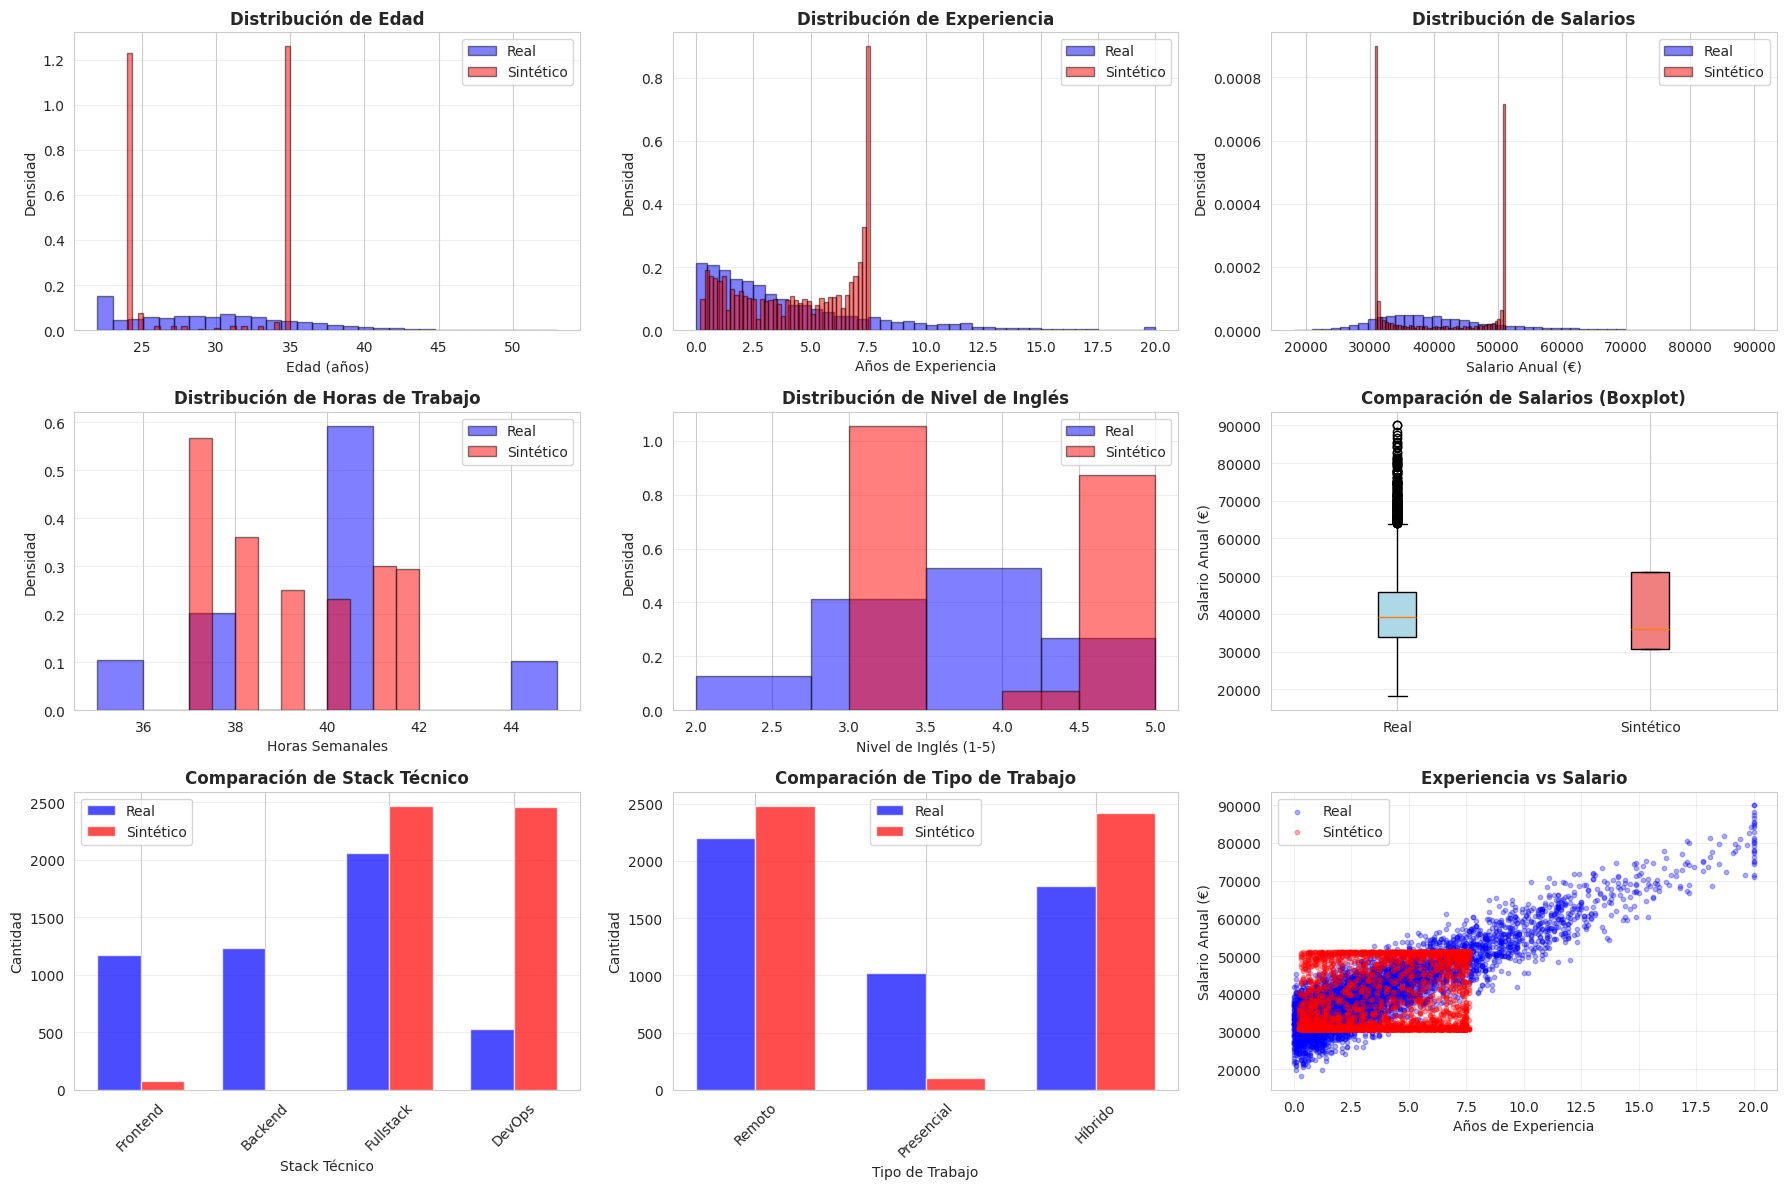

✅ Visualizaciones generadas

📊 Generando matrices de correlación...


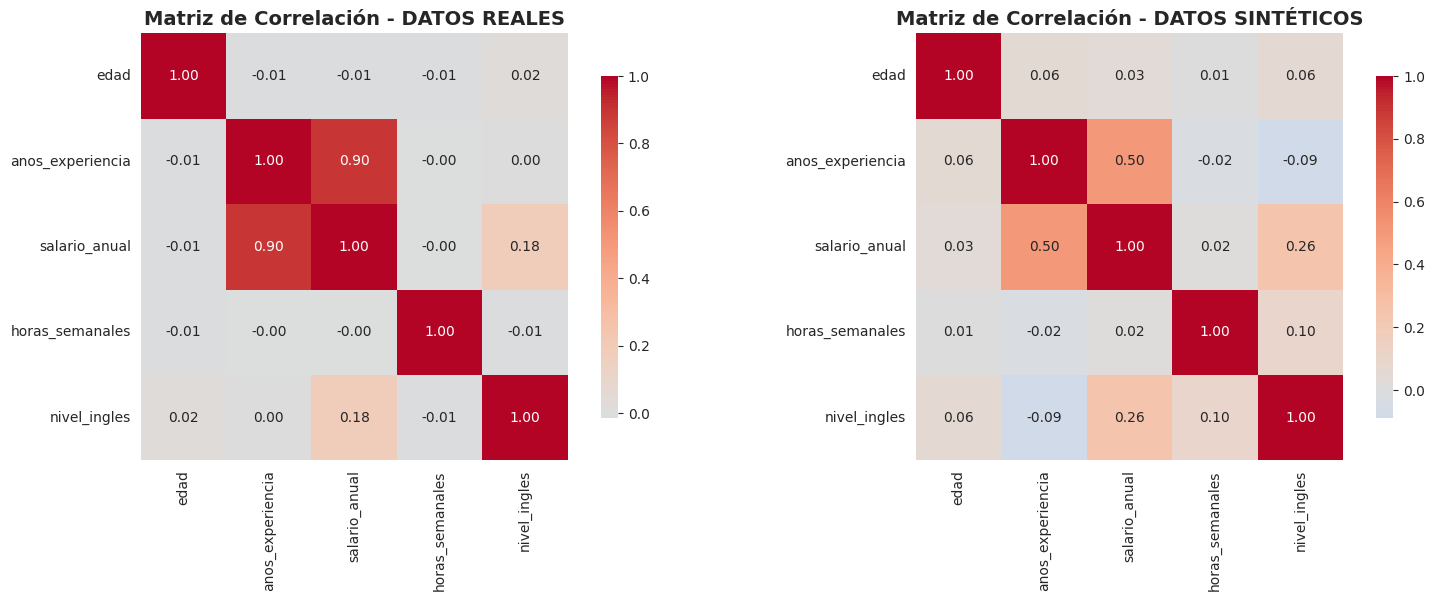

✅ Matrices de correlación generadas

📋 RESUMEN DEL ESTUDIO DE MERCADO - DESARROLLADORES WEB

1. DATOS GENERADOS:
   • Perfiles reales: 5,000
   • Perfiles sintéticos: 5,000

2. SALARIO PROMEDIO:
   • Real: 40,925 €
   • Sintético: 39,928 €

3. EXPERIENCIA PROMEDIO:
   • Real: 3.9 años
   • Sintético: 4.5 años

4. STACK MÁS DEMANDADO:
   • Real: Fullstack
   • Sintético: Fullstack

5. TIPO DE TRABAJO PREDOMINANTE:
   • Real: Remoto
   • Sintético: Remoto

✅ ESTUDIO DE MERCADO COMPLETO

💾 ¿Deseas guardar los datos sintéticos?
   Ejecuta: df_synthetic_final.to_csv('desarrolladores_sinteticos.csv', index=False)


In [ ]:
# ==============================================================================
# CELDA 13: VISUALIZACIONES COMPLETAS DEL ESTUDIO DE MERCADO
# ==============================================================================
# Análisis visual comparativo entre datos reales y sintéticos

print("="*80)
print("VISUALIZACIONES DEL ESTUDIO DE MERCADO")
print("="*80)

# ----- FIGURA 1: COMPARACIÓN DE DISTRIBUCIONES NUMÉRICAS -----
fig = plt.figure(figsize=(18, 12))

print(f"\n📊 Generando visualizaciones comparativas...")

# Lista de variables numéricas y sus configuraciones
plot_configs = [
    {'var': 'edad', 'bins': 30, 'xlabel': 'Edad (años)', 'title': 'Distribución de Edad'},
    {'var': 'anos_experiencia', 'bins': 40, 'xlabel': 'Años de Experiencia', 'title': 'Distribución de Experiencia'},
    {'var': 'salario_anual', 'bins': 50, 'xlabel': 'Salario Anual (€)', 'title': 'Distribución de Salarios'},
    {'var': 'horas_semanales', 'bins': 10, 'xlabel': 'Horas Semanales', 'title': 'Distribución de Horas de Trabajo'},
    {'var': 'nivel_ingles', 'bins': 4, 'xlabel': 'Nivel de Inglés (1-5)', 'title': 'Distribución de Nivel de Inglés'}
]

# Crear 5 subplots (uno por variable)
for i, config in enumerate(plot_configs, 1):
    plt.subplot(3, 3, i)

    # Histograma de datos reales (azul)
    plt.hist(df_original[config['var']], bins=config['bins'],
             alpha=0.5, label='Real', color='blue', edgecolor='black', density=True)

    # Histograma de datos sintéticos (rojo)
    plt.hist(df_synthetic_final[config['var']], bins=config['bins'],
             alpha=0.5, label='Sintético', color='red', edgecolor='black', density=True)

    plt.xlabel(config['xlabel'], fontsize=10)
    plt.ylabel('Densidad', fontsize=10)
    plt.title(config['title'], fontsize=12, fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(axis='y', alpha=0.3)

# ----- SUBPLOT 6: BOXPLOT COMPARATIVO DE SALARIOS -----
plt.subplot(3, 3, 6)
data_to_plot = [df_original['salario_anual'], df_synthetic_final['salario_anual']]
bp = plt.boxplot(data_to_plot, labels=['Real', 'Sintético'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
plt.ylabel('Salario Anual (€)', fontsize=10)
plt.title('Comparación de Salarios (Boxplot)', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# ----- SUBPLOT 7: STACK TÉCNICO -----
plt.subplot(3, 3, 7)
x = np.arange(len(stacks))
width = 0.35
real_counts = [df_original[df_original['stack'] == s].shape[0] for s in stacks]
synthetic_counts = [df_synthetic_final[df_synthetic_final['stack'] == s].shape[0] for s in stacks]

plt.bar(x - width/2, real_counts, width, label='Real', color='blue', alpha=0.7)
plt.bar(x + width/2, synthetic_counts, width, label='Sintético', color='red', alpha=0.7)
plt.xlabel('Stack Técnico', fontsize=10)
plt.ylabel('Cantidad', fontsize=10)
plt.title('Comparación de Stack Técnico', fontsize=12, fontweight='bold')
plt.xticks(x, stacks, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# ----- SUBPLOT 8: TIPO DE TRABAJO -----
plt.subplot(3, 3, 8)
trabajo_tipos_list = ['Remoto', 'Presencial', 'Híbrido']
x = np.arange(len(trabajo_tipos_list))
real_counts = [df_original[df_original['tipo_trabajo'] == t].shape[0] for t in trabajo_tipos_list]
synthetic_counts = [df_synthetic_final[df_synthetic_final['tipo_trabajo'] == t].shape[0] for t in trabajo_tipos_list]

plt.bar(x - width/2, real_counts, width, label='Real', color='blue', alpha=0.7)
plt.bar(x + width/2, synthetic_counts, width, label='Sintético', color='red', alpha=0.7)
plt.xlabel('Tipo de Trabajo', fontsize=10)
plt.ylabel('Cantidad', fontsize=10)
plt.title('Comparación de Tipo de Trabajo', fontsize=12, fontweight='bold')
plt.xticks(x, trabajo_tipos_list, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# ----- SUBPLOT 9: SCATTER EXPERIENCIA VS SALARIO -----
plt.subplot(3, 3, 9)
plt.scatter(df_original['anos_experiencia'], df_original['salario_anual'],
            alpha=0.3, s=10, c='blue', label='Real')
plt.scatter(df_synthetic_final['anos_experiencia'], df_synthetic_final['salario_anual'],
            alpha=0.3, s=10, c='red', label='Sintético')
plt.xlabel('Años de Experiencia', fontsize=10)
plt.ylabel('Salario Anual (€)', fontsize=10)
plt.title('Experiencia vs Salario', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizaciones generadas")

# ----- FIGURA 2: MATRIZ DE CORRELACIÓN -----
print(f"\n📊 Generando matrices de correlación...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlación de datos reales
corr_real = df_original[numeric_vars].corr()
sns.heatmap(corr_real, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Matriz de Correlación - DATOS REALES', fontsize=14, fontweight='bold')

# Correlación de datos sintéticos
corr_synthetic = df_synthetic_final[numeric_vars].corr()
sns.heatmap(corr_synthetic, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Matriz de Correlación - DATOS SINTÉTICOS', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Matrices de correlación generadas")

# ----- RESUMEN FINAL -----
print("\n" + "="*80)
print("📋 RESUMEN DEL ESTUDIO DE MERCADO - DESARROLLADORES WEB")
print("="*80)

print(f"\n1. DATOS GENERADOS:")
print(f"   • Perfiles reales: {len(df_original):,}")
print(f"   • Perfiles sintéticos: {len(df_synthetic_final):,}")

print(f"\n2. SALARIO PROMEDIO:")
print(f"   • Real: {df_original['salario_anual'].mean():,.0f} €")
print(f"   • Sintético: {df_synthetic_final['salario_anual'].mean():,.0f} €")

print(f"\n3. EXPERIENCIA PROMEDIO:")
print(f"   • Real: {df_original['anos_experiencia'].mean():.1f} años")
print(f"   • Sintético: {df_synthetic_final['anos_experiencia'].mean():.1f} años")

print(f"\n4. STACK MÁS DEMANDADO:")
print(f"   • Real: {df_original['stack'].mode()[0]}")
print(f"   • Sintético: {df_synthetic_final['stack'].mode()[0]}")

print(f"\n5. TIPO DE TRABAJO PREDOMINANTE:")
print(f"   • Real: {df_original['tipo_trabajo'].mode()[0]}")
print(f"   • Sintético: {df_synthetic_final['tipo_trabajo'].mode()[0]}")

print("\n" + "="*80)
print("✅ ESTUDIO DE MERCADO COMPLETO")
print("="*80)

# ----- OPCIONAL: GUARDAR DATOS -----
print(f"\n💾 ¿Deseas guardar los datos sintéticos?")
print(f"   Ejecuta: df_synthetic_final.to_csv('desarrolladores_sinteticos.csv', index=False)")

In [ ]:
# ==============================================================================
# CELDA 14: MÉTRICAS DE CLASIFICACIÓN (PRECISION, RECALL, F1)
# ==============================================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("="*80)
print("MÉTRICAS DEL DISCRIMINADOR")
print("="*80)

# 1. Preparar datos de evaluación (2000 reales vs 2000 sintéticos)
n_eval = 2000
X_eval_real = X_real_scaled[:n_eval]                 # Datos reales
X_eval_fake = generator.predict(np.random.normal(0, 1, (n_eval, latent_dim)), verbose=0) # Datos falsos

# Combinar datos y crear etiquetas (1=Real, 0=Falso)
X_eval = np.vstack([X_eval_real, X_eval_fake])
y_true = np.hstack([np.ones(n_eval), np.zeros(n_eval)])

# 2. Obtener predicciones
# Si la probabilidad > 0.5 lo clasifica como Real (1), si no como Falso (0)
y_pred = (discriminator.predict(X_eval, verbose=0) > 0.5).astype(int).flatten()

# 3. Calcular métricas
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# 4. Mostrar resultados
print(f"\n📊 RESUMEN DE MÉTRICAS:")
print(f"   • Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   • Precision: {precision:.4f}")
print(f"   • Recall:    {recall:.4f}")
print(f"   • F1-Score:  {f1:.4f}")

print(f"\n📋 REPORTE DETALLADO:")
print(classification_report(y_true, y_pred, target_names=['Sintético (0)', 'Real (1)']))

print("="*80)

MÉTRICAS DEL DISCRIMINADOR

📊 RESUMEN DE MÉTRICAS:
   • Accuracy:  0.5000 (50.00%)
   • Precision: 0.5000
   • Recall:    1.0000
   • F1-Score:  0.6667

📋 REPORTE DETALLADO:
               precision    recall  f1-score   support

Sintético (0)       0.00      0.00      0.00      2000
     Real (1)       0.50      1.00      0.67      2000

     accuracy                           0.50      4000
    macro avg       0.25      0.50      0.33      4000
 weighted avg       0.25      0.50      0.33      4000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
